In [9]:
import numpy as np
import pandas as pd
import neurokit2 as nk
from pathlib import Path
from tqdm import tqdm
import time

from scipy.signal import resample_poly

In [10]:
FS = 200                     # Sampling frequency (Hz)
WINDOW_SEC = 30              # Sliding window length (seconds)
WINDOW_SAMPLES = FS * WINDOW_SEC
STEP_SEC = 1                 # Step size for 1 Hz output


In [11]:
def resample_signal(signal, fs_in=256, fs_out=250):
    """
    Resample signal using polyphase filtering
    """
    return resample_poly(signal, fs_out, fs_in)

In [12]:
import warnings
warnings.filterwarnings("ignore")


In [13]:
def extract_features_from_full_gsr_ppg(df, participant_id):

    # -------------------------
    # Convert signals
    # -------------------------
    ppg = pd.to_numeric(df["ppg"], errors="coerce")
    eda = pd.to_numeric(df["gsr"], errors="coerce")

    ppg = ppg.interpolate().bfill().ffill()
    eda = eda.interpolate().bfill().ffill()

    # Resample signals to 200 Hz

    ppg = resample_signal(ppg.values, 256, 200)
    eda = resample_signal(eda.values, 256, 200)

    # -------------------------
    # Process signals
    # -------------------------
    signals_ppg, info_ppg = nk.ppg_process(ppg, sampling_rate=FS)
    signals_eda, _ = nk.eda_process(eda, sampling_rate=FS)

    # -------------------------
    # RR intervals (IBI )
    # -------------------------
    rpeaks = info_ppg["PPG_Peaks"]
    rr_intervals = np.diff(rpeaks) / FS * 1000
    rr_times = rpeaks[1:]

    features = []
    step_samples = FS * STEP_SEC

    for start in range(0, len(df) - WINDOW_SAMPLES, step_samples):

        end = start + WINDOW_SAMPLES
        window = {}

        # HR
        hr_window = signals_ppg["PPG_Rate"].iloc[start:end]
        window["HR"] = hr_window.mean(skipna=True)

        # HRV
        rr_mask = (rr_times >= start) & (rr_times < end)
        rr_win = rr_intervals[rr_mask]

        if len(rr_win) >= 5:
            diff_rr = np.diff(rr_win)
            window["HRV_RMSSD"] = np.sqrt(np.mean(diff_rr ** 2))
            window["HRV_SDNN"] = np.std(rr_win, ddof=1)
        else:
            window["HRV_RMSSD"] = np.nan
            window["HRV_SDNN"] = np.nan

        # EDA
        eda_window = signals_eda.iloc[start:end]

        window["EDA_Tonic"] = eda_window["EDA_Tonic"].mean()
        window["EDA_Phasic"] = eda_window["EDA_Phasic"].mean()
        window["SCR_Count"] = int(eda_window["SCR_Peaks"].sum())

        # Metadata
        window["participant"] = participant_id
        window["time_sec"] = start // FS

        features.append(window)

    return pd.DataFrame(features)

In [14]:
DATA_DIR = Path("../data/raw/Participants")

# -------------------------
# Collect participant files
# -------------------------
participant_files = sorted(
    DATA_DIR.rglob("full_gsr_ppg*.csv"),
    key=lambda x: int(x.parent.name.replace("Part", ""))
)
print("Found files:", len(participant_files))
for f in participant_files[:5]:
    print(f)
# -------------------------
# Select participants 1–42
# -------------------------
participant_files = participant_files[:42]

all_features = []

start_time = time.time()

for i, file in enumerate(tqdm(participant_files, desc="Processing participants")):
    participant_id = file.parent.name

    print(f"\nProcessing {participant_id} ({i+1}/{len(participant_files)})")

    df = pd.read_csv(file)

    participant_features = extract_features_from_full_gsr_ppg(
        df, participant_id
    )

    all_features.append(participant_features)

    # -------------------------
    # Time estimation
    # -------------------------
    elapsed = time.time() - start_time
    avg_time = elapsed / (i + 1)
    remaining = avg_time * (len(participant_files) - (i + 1))

    print(
        f"Elapsed: {elapsed/60:.1f} min | "
        f"Remaining: {remaining/60:.1f} min"
    )


Found files: 60
..\data\raw\Participants\Part1\full_gsr_ppg.csv
..\data\raw\Participants\Part2\full_gsr_ppg.csv
..\data\raw\Participants\Part3\full_gsr_ppg.csv
..\data\raw\Participants\Part4\full_gsr_ppg.csv
..\data\raw\Participants\Part5\full_gsr_ppg.csv


Processing participants:   0%|          | 0/42 [00:00<?, ?it/s]


Processing Part1 (1/42)


Processing participants:   2%|▏         | 1/42 [00:18<12:35, 18.44s/it]

Elapsed: 0.3 min | Remaining: 12.6 min

Processing Part2 (2/42)


...

Elapsed: 14.4 min | Remaining: 0.7 min

Processing Part41 (41/42)


Processing participants:  98%|█████████▊| 41/42 [14:43<00:20, 20.43s/it]

Elapsed: 14.7 min | Remaining: 0.4 min

Processing Part42 (42/42)


Processing participants: 100%|██████████| 42/42 [14:58<00:00, 21.39s/it]

Elapsed: 15.0 min | Remaining: 0.0 min


In [22]:
features_df = pd.concat(all_features, ignore_index=True)
features_df = features_df.dropna().reset_index(drop=True)
features_df.describe()


,HR,HRV_RMSSD,HRV_SDNN,EDA_Tonic,EDA_Phasic,SCR_Count,time_sec
count,95728.000000,95728.000000,95728.000000,95728.000000,95728.000000,95728.000000,95728.000000
mean,80.066585,71.017516,63.722988,989.700488,0.050648,0.804028,1143.245372
std,11.237376,49.696724,33.844706,4670.268338,79.127976,1.118906,663.675214
min,52.596467,6.871843,6.519202,-699.751593,-3659.799728,0.000000,0.000000
25%,71.935414,35.753174,40.107337,82.025611,-0.118234,0.000000,569.000000
50%,79.246085,55.226805,55.970741,160.136838,-0.000118,0.000000,1139.000000
75%,87.490935,92.509149,77.960749,294.204557,0.119671,1.000000,1715.000000
max,141.215822,526.236639,338.304596,84053.116883,4880.031171,12.000000,2337.000000


In [23]:

# EDA stabilization, log-transform and clip extreme values

EPS = 1e-6

features_df["EDA_Tonic_log"] = np.log(features_df["EDA_Tonic"] - features_df["EDA_Tonic"].min() + EPS)
features_df["EDA_Phasic_log"] = np.log(np.abs(features_df["EDA_Phasic"]) + EPS)

# Drop raw EDA


#Clip extreme values

features_df["HRV_RMSSD"] = features_df["HRV_RMSSD"].clip(0,200)
features_df["HRV_SDNN"] = features_df["HRV_SDNN"].clip(0,200)
features_df["EDA_Tonic_log"] = features_df["EDA_Tonic_log"].clip(-5,10)
features_df["EDA_Phasic_log"] = features_df["EDA_Phasic_log"].clip(-5,5)


In [24]:
# Feature columns used for SOM
FEATURE_COLS = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Count",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

# SOM input matrix
X_features = features_df[FEATURE_COLS]

# (Optional) metadata kept separately
metadata = features_df[["participant", "time_sec"]]


In [25]:
X_features.to_csv(    
    "../data/features_SOM_train_fulltest_200HZ.csv",
    index=False
)


In [27]:
X_features.describe()



,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,EDA_Tonic_log,EDA_Phasic_log
count,95728.000000,95728.000000,95728.000000,95728.000000,95728.000000,95728.000000
mean,80.066585,69.944343,63.603372,0.804028,6.939971,-2.111259
std,11.237376,45.891563,33.244119,1.118906,0.609628,1.656869
min,52.596467,6.871843,6.519202,0.000000,-5.000000,-5.000000
25%,71.935414,35.753174,40.107337,0.000000,6.661570,-3.187862
50%,79.246085,55.226805,55.970741,0.000000,6.756803,-2.129776
75%,87.490935,92.509149,77.960749,1.000000,6.901693,-1.171207
max,141.215822,200.000000,200.000000,12.000000,10.000000,5.000000


In [28]:
X_features.shape

(95728, 6)

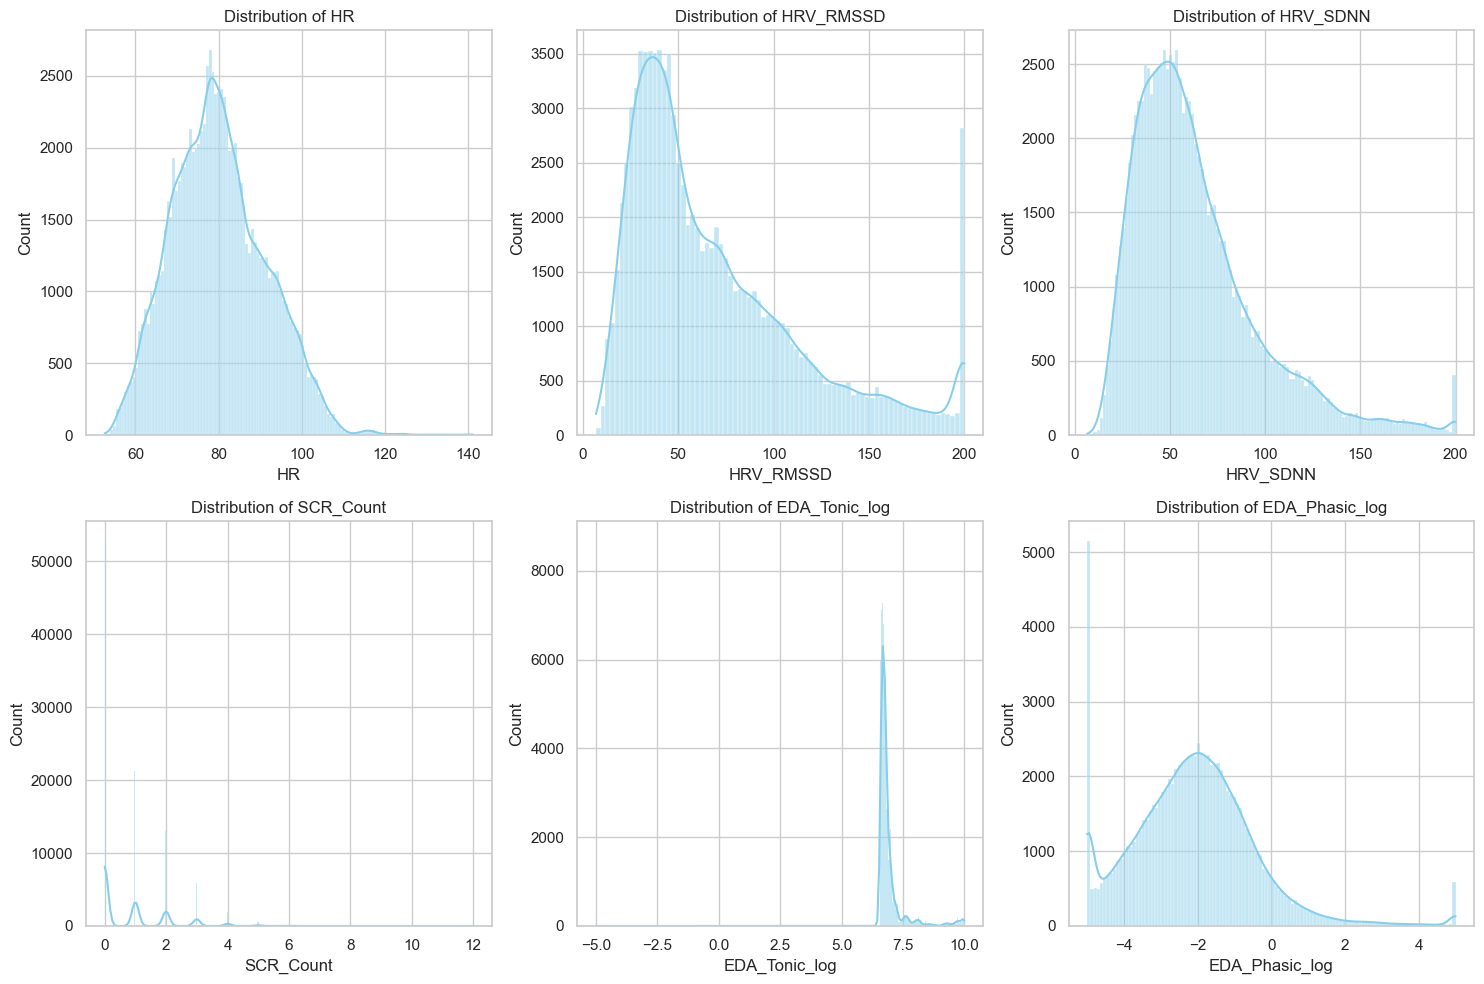

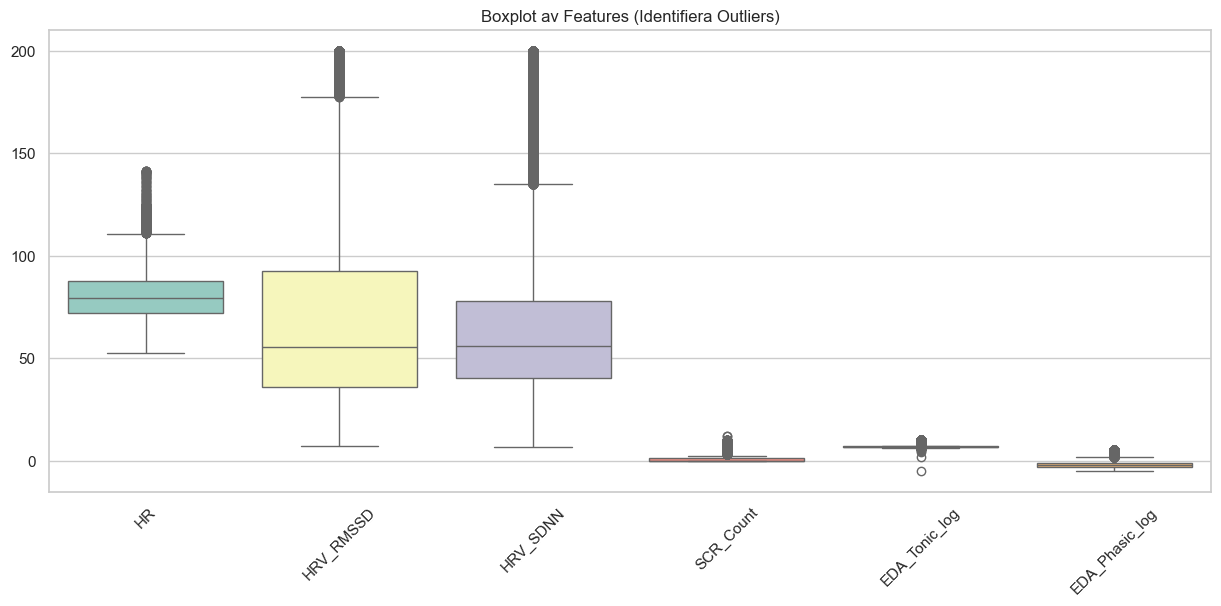

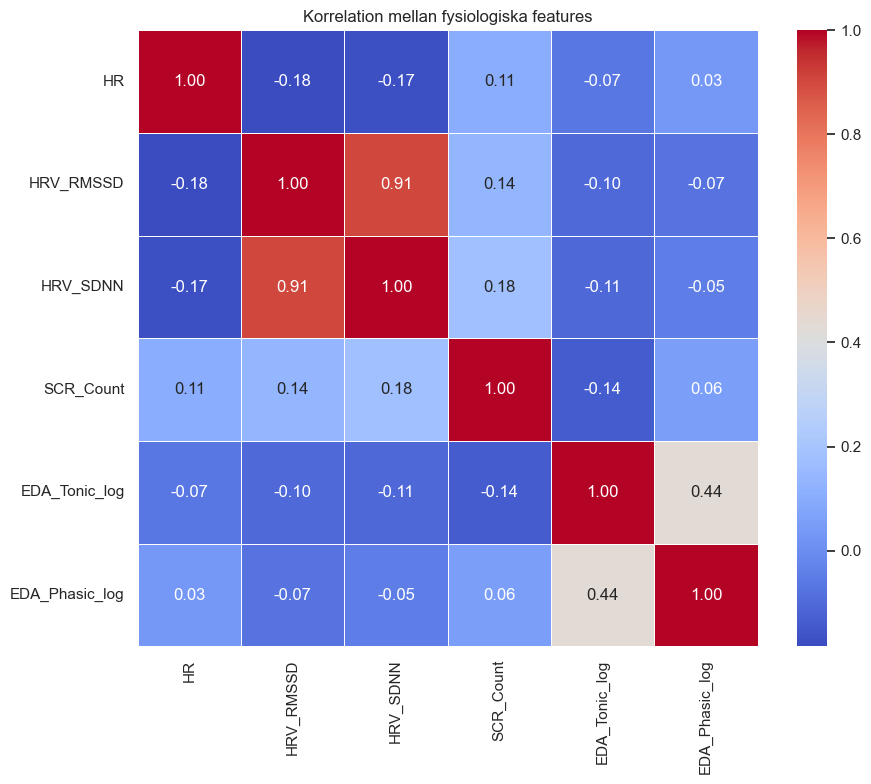

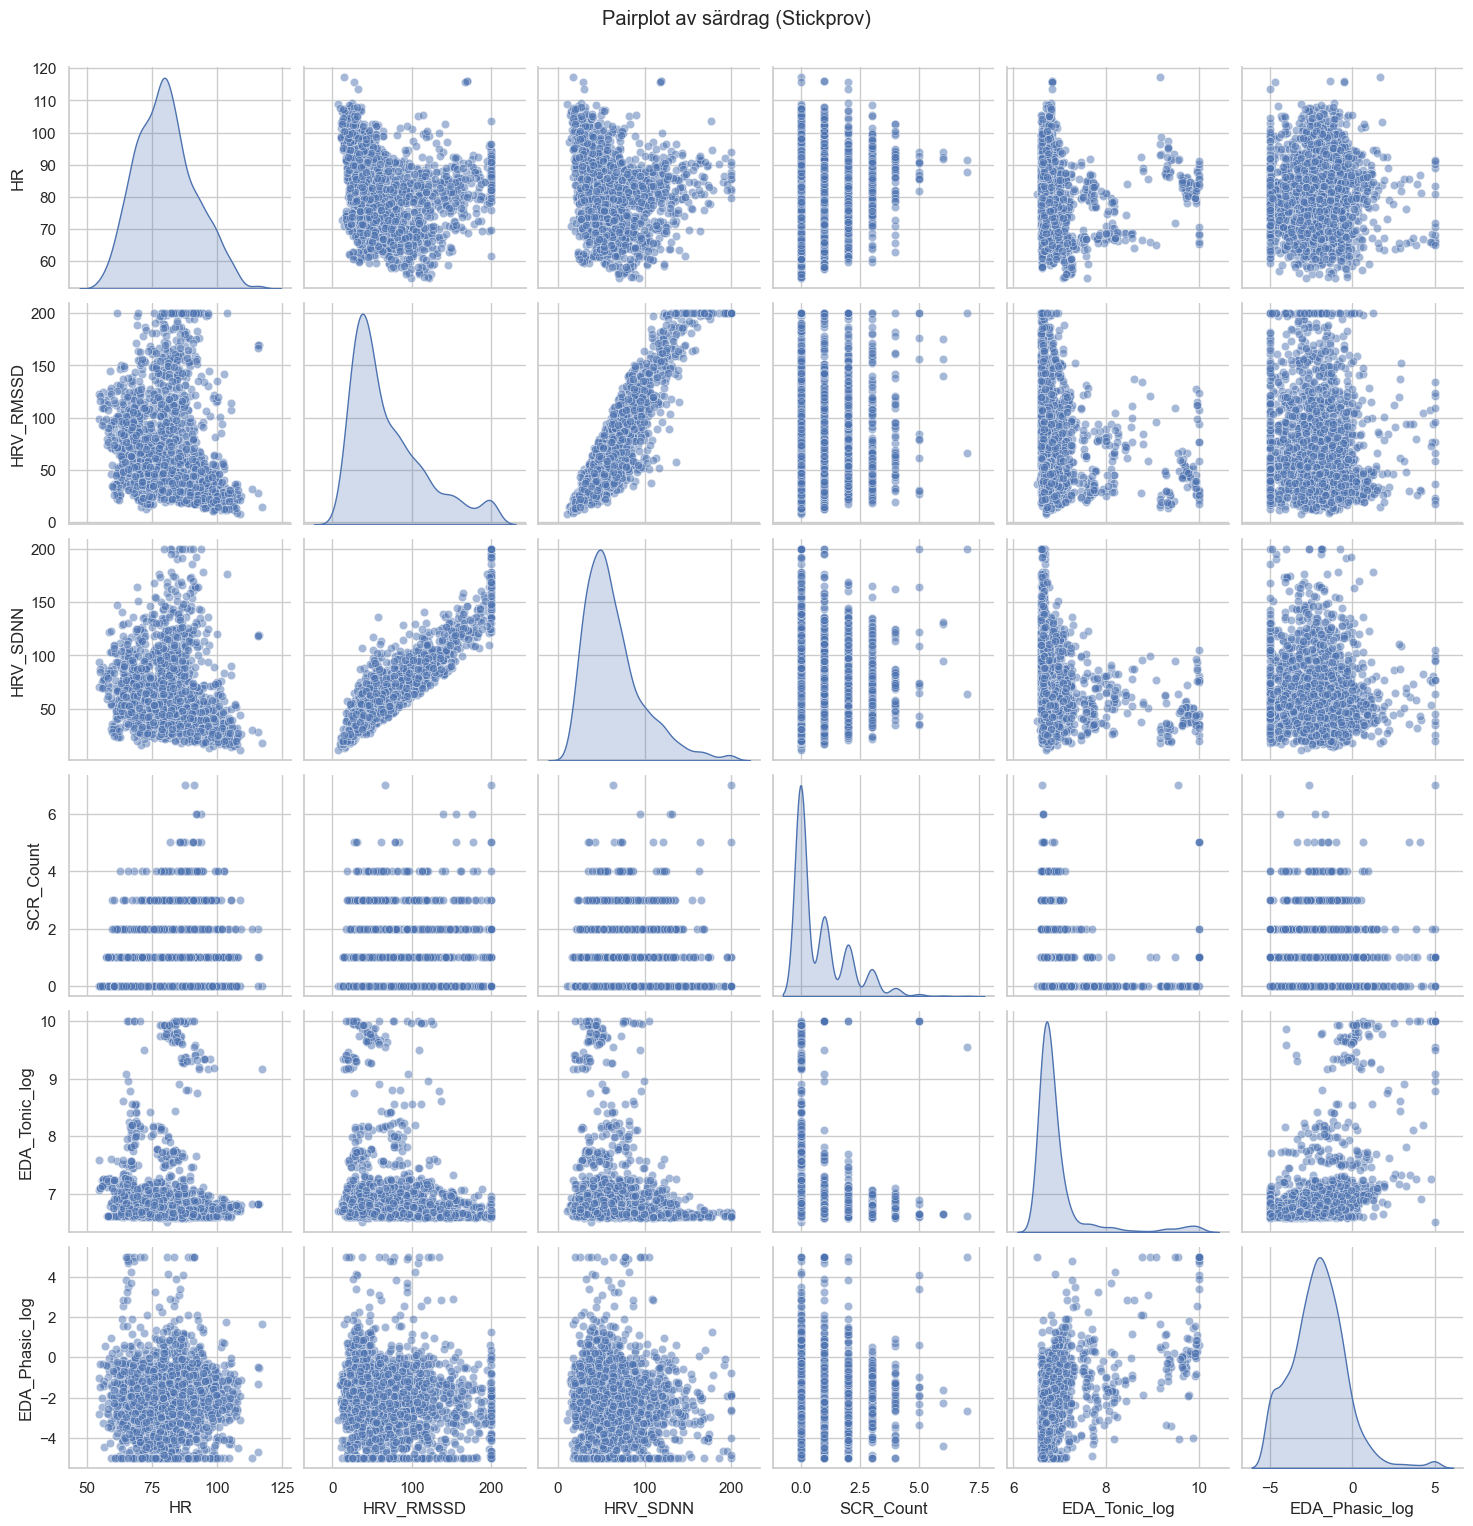

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ställ in stil
sns.set(style="whitegrid")
cols_to_plot = ['HR', 'HRV_RMSSD', 'HRV_SDNN', 'SCR_Count', 'EDA_Tonic_log', 'EDA_Phasic_log']

### 1. Fördelning (Histograms & KDE)
# Hjälper oss se om data är normalfördelad eller skev
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(features_df[col], kde=True, color="skyblue")
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 2. Boxplots (Outlier-detektion)
# Viktigt för SOM eftersom den är känslig för extrema avstånd
plt.figure(figsize=(15, 6))
sns.boxplot(data=features_df[cols_to_plot], palette="Set3")
plt.xticks(rotation=45)
plt.title('Boxplot av Features (Identifiera Outliers)')
plt.show()

### 3. Korrelationsmatris (Heatmap)
# Visar om vissa features är redundanta (t.ex. RMSSD vs SDNN)
plt.figure(figsize=(10, 8))
corr = features_df[cols_to_plot].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korrelation mellan fysiologiska features')
plt.show()

### 4. Pairplot (Relationer mellan variabler)
# Tar en stund att köra men visar kluster-tendenser direkt
# Vi samplar 2000 rader för att det ska gå snabbt
sns.pairplot(features_df[cols_to_plot].sample(2000), diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot av särdrag (Stickprov)', y=1.02)
plt.show()